### Dans ce notebook avec les statistiques descriptives, nous détaillons la méthodologie d'aggrégation des données d'interaction et des impayés

In [43]:
!pip install matplotlib
!pip install seaborn
!pip install fsspec
!pip install s3fs

In [44]:
import os
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
df_interaction = pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_interactions_2023_11.csv", sep=";")
df_interaction.head()

,client_code,interaction_motif,interaction_precision,interaction_canal,interaction_date,interaction_service,interaction_est_transferee_service_reclamation,interaction_est_transferee_service_gestion,interaction_est_transferee_service_commercial,interaction_est_externalisee,interaction_texte_mail
0,12570111,Tiers payant,Duplicata carte Tiers-payant,Téléphone,2022-12-28,Suivi du contrat,0,0,0,1,NaN
1,15029743,Montant des cotisations,Taux / Montant de cotisations,E-mail,2022-12-09,Cotisations & Recouvrements,0,1,0,0,xxpj0 xxobj TR: ALPTIS augmentation prime 20...
2,11345727,Tiers payant,Duplicata carte Tiers-payant,Téléphone,2022-12-12,Suivi du contrat,0,0,0,1,NaN
3,14067838,Médecine douce,Justificatif facture,E-mail,2022-12-07,Prestations santé,0,1,0,0,xxpj0 Scan_06122022163209 xxobj flag_client_ ...
4,10205168,Demande de documents,Avis d'échéance,Téléphone,2022-12-08,Cotisations & Recouvrements,0,1,0,1,NaN


In [46]:
#Dimensions
df_interaction.shape

(251793, 11)

In [47]:
# Le nombre de clients ayant eu au moins une interaction avec Alptis
print(df_interaction['client_code'].nunique(), df_interaction['interaction_motif'].nunique())



65895 34


🖍️🖍️ Sur la période, les clients ont eu 251793 interactions avec Alptis mais ces interactions ne concernent que 65895 clients soit environ 50% des clients d'Alptis. On compte 34 motifs pour ces interactions 

In [48]:
# Analysons la fréquence des interactions des clients 
freq_interactions = df_interaction.groupby('client_code').size()
freq_interactions.describe()

count    65895.000000
mean         3.821125
std          4.499766
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        224.000000
dtype: float64

In [49]:
freq_interactions.sort_values(ascending=False).head(10)

client_code
7943181     224
15205289    137
15545468    113
3947217      86
15238945     81
15689381     79
14137761     79
14770925     74
14480278     65
14902798     63
dtype: int64

🖍️🖍️La moitié des clients ayant eu au moins une fois des interactions avec Alptis n'ont pas eu plus de 2 interactions avec Alptis. 
Mais 25% de ces clients on eu plus de 5 interactions avec 3 clients dépassant les 100: ce qui tire la moyenne vers 4 interactions par client au cours de la période 

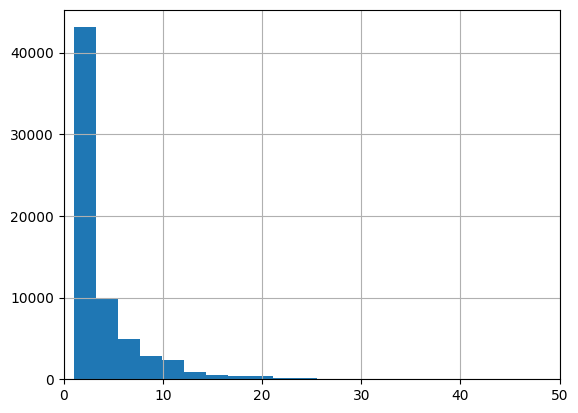

In [50]:
freq_interactions.hist(bins=100)
plt.xlim(0, 50)
plt.show()

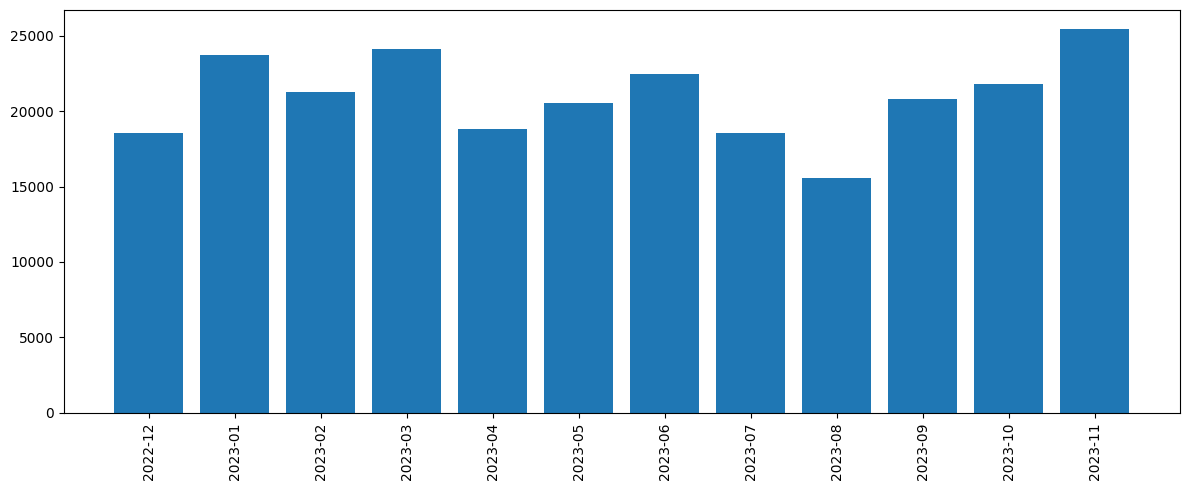

interaction_date,2022-12,2023-01,2023-02,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11
0,18525,23729,21290,24160,18824,20532,22503,18552,15592,20804,21836,25446


In [51]:
df_interaction['interaction_date'] = pd.to_datetime(df_interaction['interaction_date'])

freq_par_mois = df_interaction.groupby(df_interaction['interaction_date'].dt.to_period('M')).size()
freq_par_mois = pd.DataFrame(freq_par_mois).T
freq_par_mois.columns = freq_par_mois.columns.astype(str)

freq_par_mois_T = freq_par_mois.T

plt.figure(figsize=(12, 5))
plt.bar(freq_par_mois_T.index, freq_par_mois_T[0])
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

freq_par_mois

In [52]:
# Fréquence des motifs d'interactions 
df_interaction['interaction_motif'].value_counts(normalize=True) * 100

interaction_motif
Frais courants                                  15.200979
Dentaire                                        11.937584
Hospitalisation                                 10.437145
Télétransmission                                 7.670189
Médecine douce                                   7.560576
Tiers payant                                     7.185664
Optique                                          6.641567
Données administratives                          3.891689
Adhésion                                         3.859917
Modalités de règlement                           3.230034
Demande de documents                             3.139086
Résiliation                                      2.954808
Montant des cotisations                          2.684745
Demandes générales                               2.330486
Audioprothèse                                    2.096166
Cures thermales                                  1.659697
Modification de garantie                         1.647

Pour cette variable nous suggérons la création des variables en prenant les 7 plus fréquents motifs et les autres dans une variable autre_motifs

In [53]:
# Fréquence des motifs d'interactions 
df_interaction['interaction_precision'].nunique()

101

Non seulement la variable interaction_precision a beaucoup de modalités, nous pensons qu'elle n'est un detail ou une précision des motifs: elle sera donc supprimée des variables à garder dans l'aggrégation 

In [54]:
# Fréquence des motifs d'interactions 
df_interaction['interaction_canal'].value_counts(normalize=True) * 100

interaction_canal
Téléphone    61.690357
E-mail       38.309643
Name: proportion, dtype: float64

Deux canaux: Téléphone et E-mail. Nous allons créer deux variables: nb_interaction_email et nb_interaction_tel

In [55]:
# Fréquence des motifs d'interactions 
df_interaction['interaction_service'].value_counts(normalize=True) * 100

interaction_service
Prestations santé              58.202968
Suivi du contrat               31.499684
Cotisations & Recouvrements     9.204386
Prestations prévoyance          0.691441
Devis                           0.401520
Name: proportion, dtype: float64

Trois variables pour les services les plus fréquents et une variable autres_services

In [56]:
df_interaction[
    [
        "interaction_est_transferee_service_reclamation",
        "interaction_est_transferee_service_gestion",
        "interaction_est_transferee_service_commercial",
        "interaction_est_externalisee"
    ]
].describe()


,interaction_est_transferee_service_reclamation,interaction_est_transferee_service_gestion,interaction_est_transferee_service_commercial,interaction_est_externalisee
count,251793.000000,251793.000000,251793.000000,251793.000000
mean,0.000405,0.464219,0.004067,0.462284
std,0.020123,0.498719,0.063642,0.498577
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,0.000000,1.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000


Très peu d'intéractions ont été transféré aux services reclamation et commercial.
Presque la moitié transférée soit au service gestion ou soit externalisée 

### Méthode d'agrégation de la base interaction

##### Nous allons regrouper les information par client en procédant comme suit:
  
  🔰interaction_motif: Pour cette variable nous suggérons la création des variables en prenant les 7 plus fréquents motifs et les autres dans une variable autre_motifs
  
  🔰interaction_precision: a beaucoup de modalités, nous pensons qu'elle n'est un detail ou une précision des motifs: elle sera donc supprimée des variables à garder dans l'agrégation 
  
  🔰Deux canaux: Téléphone et E-mail. Nous allons créer deux variables: nb_interaction_email et nb_interaction_tel
  
  🔰Trois variables pour les services les plus fréquents et une variable autres_services

  🔰Pour les 4 dummies, on les garde mais on prends cette fois ci les nombres d'interactions transférées à chaque services

  🔰 Pour les contenues des mails, nous allons créer un dictionnaire pour chaque client et chaque texte aura pour clé la date de l'envoi du mail
  




In [57]:
nb_interactions_total = (
    df_interaction
    .groupby("client_code")
    .size()
    .to_frame("nb_interactions_total")
)
nb_interactions_total

,nb_interactions_total
client_code,
22037,2
22331,10
22702,8
23003,1
23164,2
...,...
16201438,1
16201746,1
16201837,1


In [58]:
# =====================================================
# CREATION DU DATAFRAME FINAL AVEC LES 8 VARIABLES MOTIFS
# =====================================================

df = df_interaction.copy()

# 1. Les 7 motifs principaux
top7 = [
    "Frais courants",
    "Dentaire",
    "Hospitalisation",
    "Télétransmission",
    "Médecine douce",
    "Tiers payant",
    "Optique"
]

# 2. Création de la variable "motif_simplifie"
df["motif_simplifie"] = df["interaction_motif"].apply(
    lambda x: x if x in top7 else "autres_motifs"
)

# 3. Création du dataframe final directement rempli
df_motif = (
    df.groupby(["client_code", "motif_simplifie"])
      .size()
      .unstack(fill_value=0)
)

# 4. Renommage des colonnes
df_motif = df_motif.rename(columns={
    "Frais courants": "motif_frais_courants",
    "Dentaire": "motif_dentaire",
    "Hospitalisation": "motif_hospitalisation",
    "Télétransmission": "motif_teletransmission",
    "Médecine douce": "motif_medecine_douce",
    "Tiers payant": "motif_tiers_payant",
    "Optique": "motif_optique",
    "autres_motifs": "autres_motifs"
})

# Résultat
df_motif.head()


motif_simplifie,motif_dentaire,motif_frais_courants,motif_hospitalisation,motif_medecine_douce,motif_optique,motif_tiers_payant,motif_teletransmission,autres_motifs
client_code,,,,,,,,
22037,0,0,0,0,0,0,0,2
22331,0,0,2,0,4,0,0,4
22702,0,1,4,0,0,0,0,3
23003,0,1,0,0,0,0,0,0
23164,0,1,0,0,0,0,0,1


In [59]:
# =====================================================
# CREATION DU DATAFRAME df_service (4 VARIABLES)
# =====================================================

df = df_interaction.copy()

# 1. Les 3 services principaux
top3_services = [
    "Prestations santé",
    "Suivi du contrat",
    "Cotisations & Recouvrements"
]

# 2. Création de la variable simplifiée
df["service_simplifie"] = df["interaction_service"].apply(
    lambda x: x if x in top3_services else "autres_services"
)

# 3. Comptage par client + service
df_service = (
    df.groupby(["client_code", "service_simplifie"])
      .size()
      .unstack(fill_value=0)
)

# 4. Renommage manuel des colonnes
df_service = df_service.rename(columns={
    "Prestations santé": "service_prestations_sante",
    "Suivi du contrat": "service_suivi_du_contrat",
    "Cotisations & Recouvrements": "service_cotisations_recouvrements",
    "autres_services": "autres_services"
})

# 5. Vérification
df_service.head()


service_simplifie,service_cotisations_recouvrements,service_prestations_sante,service_suivi_du_contrat,autres_services
client_code,,,,
22037,0,0,0,2
22331,0,10,0,0
22702,0,8,0,0
23003,0,1,0,0
23164,0,2,0,0


In [60]:
# =====================================================
# CREATION DE df_canal (UNIQUEMENT TELEPHONE)
# =====================================================

df = df_interaction.copy()


# 2. Filtrer uniquement les interactions téléphone
df_tel = df[df["interaction_canal"] == "Téléphone"]

# 3. Compter les interactions téléphone par client
df_canal = (
    df_tel.groupby("client_code")
          .size()
          .to_frame("nb_interaction_telephone")
)

# 4. Si un client n’a pas de téléphone → mettre 0
df_canal["nb_interaction_telephone"] = df_canal["nb_interaction_telephone"].fillna(0)

# Vérification
df_canal.head()



,nb_interaction_telephone
client_code,
22037,1
22331,10
22702,8
23003,1
23164,2


In [61]:
# =====================================================
# CREATION DE df_transfert (4 VARIABLES DE TRANSFERTS)
# =====================================================

df = df_interaction.copy()

# 1. Liste des 4 dummies à agréger
dummies_transfert = [
    "interaction_est_transferee_service_reclamation",
    "interaction_est_transferee_service_gestion",
    "interaction_est_transferee_service_commercial",
    "interaction_est_externalisee"
]

# 2. Somme par client des 4 indicateurs
df_transfert = (
    df.groupby("client_code")[dummies_transfert]
      .sum()
)

# 3. Renommage propre des colonnes
df_transfert = df_transfert.rename(columns={
    "interaction_est_transferee_service_reclamation": "nb_transferts_reclamation",
    "interaction_est_transferee_service_gestion": "nb_transferts_gestion",
    "interaction_est_transferee_service_commercial": "nb_transferts_commercial",
    "interaction_est_externalisee": "nb_transferts_externalises"
})

# Vérification
df_transfert.head()


,nb_transferts_reclamation,nb_transferts_gestion,nb_transferts_commercial,nb_transferts_externalises
client_code,,,,
22037,0,1,0,1
22331,0,5,0,7
22702,0,4,0,8
23003,0,0,0,1
23164,0,2,0,2


In [62]:
# =====================================================
# CREATION DE df_historique_mails (DICTIONNAIRE PAR CLIENT)
# =====================================================

df = df_interaction.copy()


# 2. Filtrer uniquement les mails
df_mail = df[df["interaction_canal"] == "E-mail"]

# 3. Création du dictionnaire {date : texte_mail} pour chaque client
df_historique_mails = df_mail.groupby("client_code").apply(
    lambda x: dict(zip(x["interaction_date"], x["interaction_texte_mail"]))
).to_frame("historique_mails")

# 4. Remplir les clients sans mail par dictionnaire vide
df_historique_mails["historique_mails"] = df_historique_mails["historique_mails"].fillna({})

# 5. Vérification
df_historique_mails.head()


/tmp/ipykernel_91821/2488015598.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_historique_mails = df_mail.groupby("client_code").apply(


,historique_mails
client_code,
22037,{2023-01-24 00:00:00: 'xxpj0 xxobj Adhérent 3...
23318,{2023-02-01 00:00:00: 'xxpj0 processed-429b95a...
25355,{2023-09-14 00:00:00: 'xxpj0 Scan_20230914_115...
25663,{2023-11-06 00:00:00: 'xxpj0 xxobj CABINET DR...
27623,{2023-07-07 00:00:00: 'xxpj0 2023-06 Attestati...


In [ ]:
df_historique_mails[historique_mails].describe()

KeyboardInterrupt: 